JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


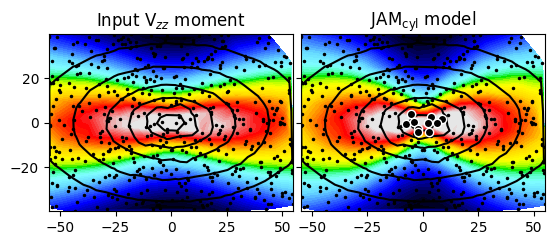

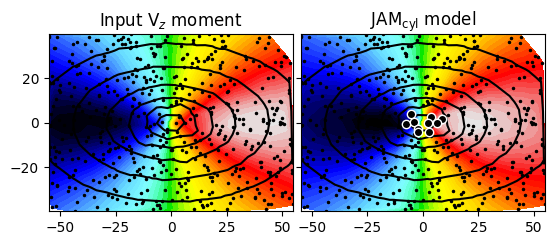

In [1]:
# IMPORTANT: Restart kernel before running this cell, so backend selection is fresh.
import os
# Optional: pin to one GPU index if needed.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
# Avoid inheriting problematic platform filters (e.g. rocm) from environment.
os.environ.pop("JAX_PLATFORMS", None)

import numpyro
# Use NumPyro helper to request GPU backend.
numpyro.set_platform("gpu")

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())
if jax.default_backend() not in ("gpu", "cuda", "rocm"):
    raise RuntimeError("GPU backend not active. Check CUDA/JAX installation and visible devices.")

from jax.tree_util import Partial as partial
import time
import matplotlib.pyplot as plt
from jax.scipy import special, signal, ndimage
from time import perf_counter as clock
from plotbin.plot_velfield import plot_velfield
from plotbin.symmetrize_velfield import symmetrize_velfield
from jam_axi_intr import mom_interp
import nquad as nq
import numpy as np

from jam_axi_proj_jax import jam_axi_proj

np.random.seed(123)
xbin, ybin = np.random.uniform(low=[-55, -40], high=[55, 40], size=[500, 2]).T

inc = 60.                                                # Assumed galaxy inclination
r = jnp.sqrt(xbin**2 + (ybin/jnp.cos(jnp.radians(inc)))**2) # Radius in the plane of the disk
a = 40                                                   # Scale length in arcsec
vr = 2000*jnp.sqrt(r)/(r + a)                             # Assumed velocity profile (v_c of Hernquist 1990)
vel = vr * jnp.sin(jnp.radians(inc))*xbin/r                # Projected velocity field
sig = 8700/(r + a)                                       # Assumed velocity dispersion profile
rms = jnp.sqrt(vel**2 + sig**2)                           # Vrms field in km/s

surf = jnp.array([39483., 37158., 30646., 17759., 5955.1, 1203.5, 174.36, 21.105, 2.3599, 0.25493])
sigma = jnp.array([0.153, 0.515, 1.58, 4.22, 10, 22.4, 48.8, 105, 227, 525])
qobs = jnp.full_like(sigma, 0.57)

distance = 16.5     # Assume Virgo distance in Mpc (Mei et al. 2007)
mbh = 1e8           # Black hole mass in solar masses
beta = jnp.full_like(surf, 0.2)
# beta = jnp.array([1.0,0.2,0.2,1.0])

surf_lum = surf_pot = surf
sigma_lum = sigma_pot = sigma
qobs_lum = qobs_pot = qobs

sigmapsf =  jnp.array([0.6, 1.2])
normpsf = jnp.array([0.7, 0.3])
pixsize = 0.8
goodbins = r > 10  # Arbitrarily exclude the center to illustrate how to use goodbins

# I use a loop below, just to highlight the fact that all parameters
# remain the same for the two JAM calls, except for 'moment' and 'data'

from functools import partial
jam_obj = jam_axi_proj()

for moment, data in zip(['zz', 'z'], [rms, vel]):

        _ = jam_obj.get_kinematics(surf_lum = surf_lum, sigma_lum=sigma_lum, qobs_lum=qobs_lum, surf_pot=surf_pot, sigma_pot=sigma_pot, qobs_pot=qobs_pot,
                            inc=inc, mbh=mbh, distance=distance, xbin=xbin, ybin=ybin, data=data,
                            sigmapsf=sigmapsf, normpsf=normpsf, beta=beta, pixsize=pixsize,logistic = False,
                            moment=moment, goodbins=goodbins, align='cyl', ml=None,quiet=True)

        # The model is by design similar but not identical to the adopted kinematics!
        model, chi2, flux, ml, vel, vel2 = _

        jam_obj.plot(goodbins,moment,model,xbin,ybin,data,'cyl',flux, nodots=False)
        plt.show()

from numpyro.infer import MCMC, NUTS
from numpyro import distributions as dist
import numpyro

surf_lum = jnp.array(surf_lum)
jam_eval = partial(jam_obj.get_kinematics, sigma_lum=sigma_lum, qobs_lum=qobs_lum, 
                   surf_pot=surf_pot, sigma_pot=sigma_pot, qobs_pot=qobs_pot,
                    inc=inc, mbh=mbh, distance=distance, xbin=xbin, ybin=ybin, data=data,
                    sigmapsf=sigmapsf, normpsf=normpsf, beta=beta, pixsize=pixsize,logistic=False,step = 0.05,
                    moment=moment, goodbins=goodbins, align='cyl', ml=None,quiet=True)


328.2751120028642


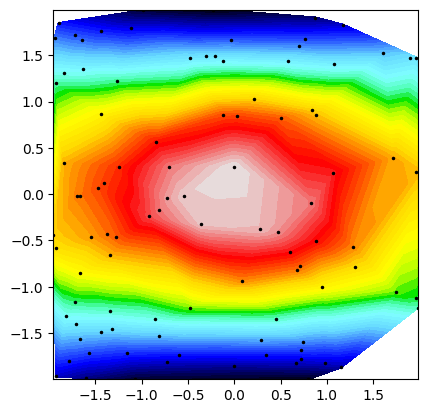

In [2]:
from SLCOSMO import tool
from MGE_jax import MGE
import pickle as pkl
from herculens.Util import param_util
file = 'lens_light_jackpot.pkl'
lens_light = pkl.load(open(file, 'rb'))[0]
surf_lum_jackpot = lens_light['amp']
sigma_lum_jackpot = lens_light['sigma']
phi, qobs_lum_jackpot = param_util.ellipticity2phi_q(lens_light['e1'], lens_light['e2'])
# qobs_lum_jackpot = qobs_lum_jackpot/qobs_lum_jackpot
beta_jackpot = jnp.full_like(surf_lum_jackpot, 0.0)


xbin, ybin = np.random.uniform(low=[-2, -2], high=[2, 2], size=[100, 2]).T
cosmology = {'Omegam': 0.3, 'Omegak': 0.0, 'w0': -1.0, 'wa': 0.0, 'h0': 70.0}
kwargs_epl = {'thetaE': 2, 'gamma': 2, 'zl': 0.2, 'zs': 0.4, 'cosmology':cosmology}
dl, ds, dls = tool.dldsdls(0.2, 0.4, cosmology, n=20)
distance = dl[0]
mge_epl = MGE(tool.EPL_msunmpc, 'thetaE', n_gauss=10, n_terms=28, sigma_start_mult=1/100, sigma_end_mult=50)
mass_amplitude, mass_sigma = mge_epl.decompose(**kwargs_epl)

surf_pot = mass_amplitude
sigma_pot = mass_sigma
qobs_pot = jnp.full_like(mass_amplitude, 0.9)


jam_obj = jam_axi_proj()
_ = jam_obj.get_kinematics(surf_lum = surf_lum_jackpot, sigma_lum=sigma_lum_jackpot, qobs_lum=qobs_lum_jackpot, 
                           surf_pot=surf_pot, sigma_pot=sigma_pot, qobs_pot=qobs_pot,
                    inc=90, mbh=0.0, distance=distance, xbin=xbin, ybin=ybin,step = 0.05,
                    sigmapsf=sigmapsf, normpsf=normpsf, beta=beta_jackpot, pixsize=pixsize,logistic = False,
                    moment='zz', align='cyl', ml=None,quiet=True)
model, chi2, flux, ml, vel, vel2  = _

plot_velfield(xbin, ybin, jnp.clip(model,-1e3,1e3))
print(model.mean())

In [3]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC, init_to_median

key = jax.random.PRNGKey(42)
err_sigma = 20.0  # km/s per pixel

model_true = model
noise = err_sigma * jax.random.normal(key, shape=model_true.shape)
sigma_obs_full = model_true + noise
sigma_obs = sigma_obs_full
x_obs = xbin
y_obs = ybin

jam_eval = partial(jam_obj.get_kinematics,         
                   surf_lum = surf_lum_jackpot,
                    sigma_lum = sigma_lum_jackpot,
                    qobs_lum = qobs_lum_jackpot,
                    inc = 90.0,
                    mbh = 0.0,
                    distance = distance,
                    xbin = xbin,
                    ybin = ybin,
                    sigmapsf = sigmapsf,
                    normpsf = normpsf,
                    pixsize = pixsize,
                    logistic = False,
                    step = 0.05,
                    moment = 'zz',
                    align = 'cyl',
                    ml = None,
                    quiet = True)

def lens_kinematics_model(sigma_obs):

    # --- Priors ---
    thetaE = numpyro.sample("thetaE", dist.Uniform(1.9, 2.1))      # arcsec-ish
    gamma  = numpyro.sample("gamma",  dist.Uniform(1.6, 2.4))      # EPL slope
    beta   = numpyro.sample("beta",   dist.Uniform(-0.5, 0.8))     # JAM anisotropy
    q      = numpyro.sample("q",      dist.Uniform(0.3, 1))         # EPL axis ratio

    beta_vec = jnp.full_like(surf_lum_jackpot, beta)

    mass_amp, mass_sig = mge_epl.decompose(
        thetaE=thetaE, gamma=gamma,
        zl=kwargs_epl["zl"], zs=kwargs_epl["zs"], cosmology=kwargs_epl["cosmology"]
    )
    qobs_pot_local = jnp.full_like(mass_amp, q)

    pred_model, *_ = jam_eval(
                surf_pot = mass_amp,
                sigma_pot = mass_sig,
                beta = beta_vec,
                qobs_pot = qobs_pot_local
    )

    sigma = err_sigma * jnp.ones_like(pred_model)

    with numpyro.plate("pixels", pred_model.size):
        numpyro.sample("obs", dist.Normal(pred_model, sigma), obs=sigma_obs)

nuts = NUTS(lens_kinematics_model, init_strategy=init_to_median(), target_accept_prob=0.8)
mcmc = MCMC(nuts, num_warmup=500, num_samples=1500, num_chains=4, progress_bar=True, chain_method='vectorized')

rng = jax.random.PRNGKey(0)
mcmc.run(rng, sigma_obs=sigma_obs)

sample: 100%|██████████| 2000/2000 [35:30<00:00,  1.07s/it] 


divergences per chain per step:
 [0 0 0 0]


/tmp/ipykernel_744337/2323325282.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


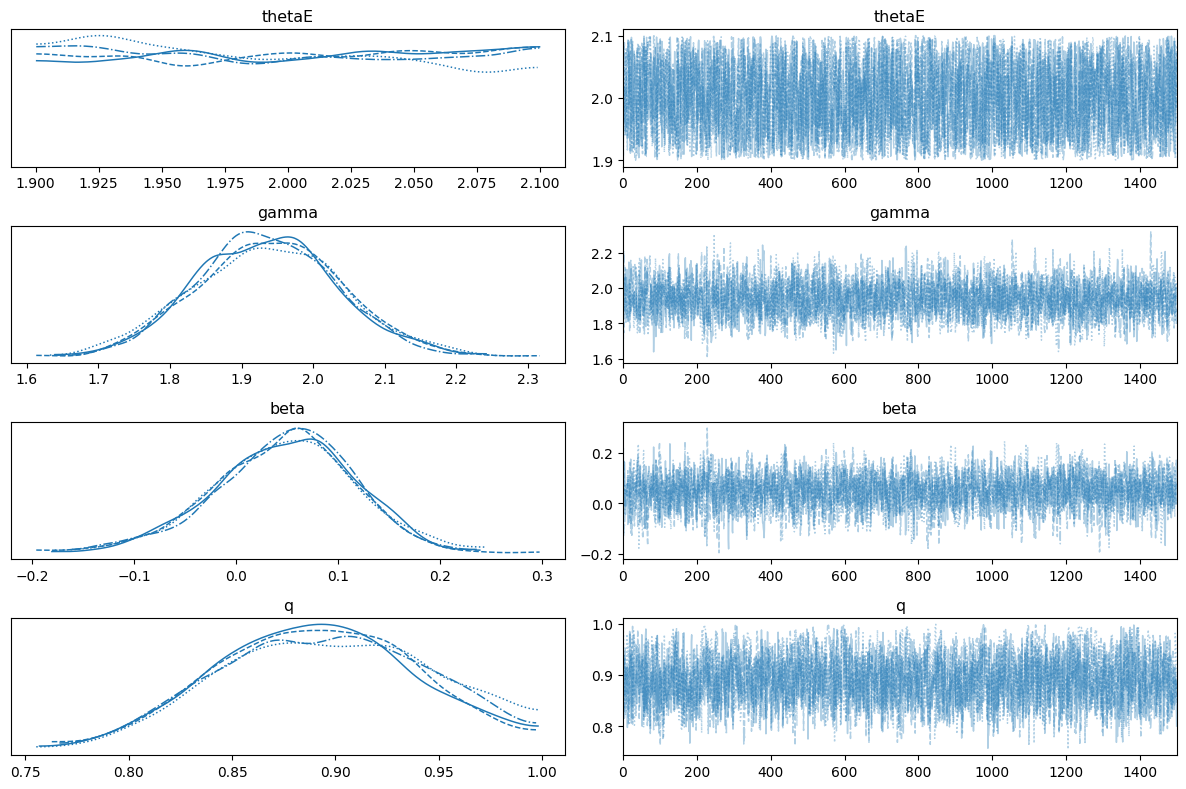

In [4]:
import arviz as az
import corner as corner
inf_data = az.from_numpyro(mcmc)
print(f'divergences per chain per step:\n {inf_data.sample_stats.diverging.values.sum(axis=1).T}')
plt.rcParams['figure.constrained_layout.use'] = True
_ = az.plot_trace(inf_data, var_names=['thetaE', 'gamma', 'beta', 'q'])
plt.tight_layout()

divergences per chain per step:
 [0 0 0 0]


/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


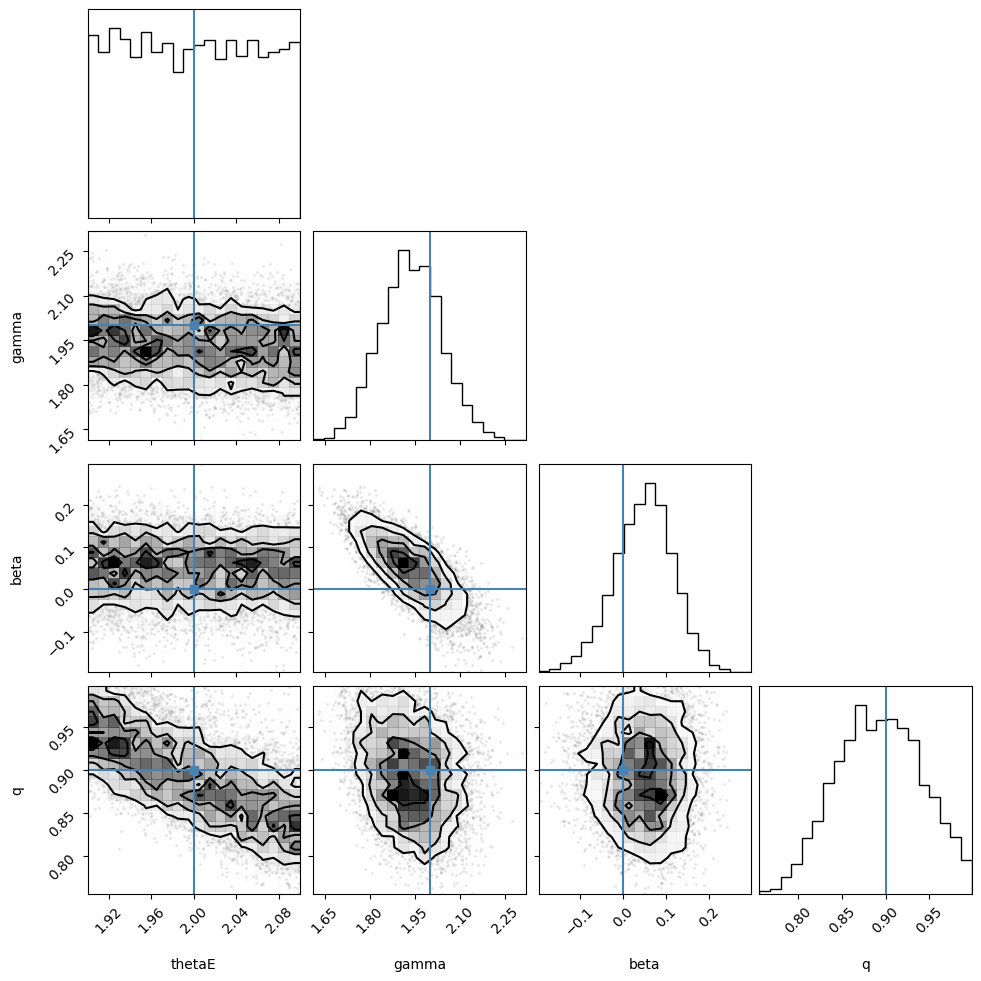

In [5]:
import arviz as az
import corner as corner
inf_data = az.from_numpyro(mcmc)
print(f'divergences per chain per step:\n {inf_data.sample_stats.diverging.values.sum(axis=1).T}')

varnames = ['thetaE','gamma','beta', 'q']
az.summary(inf_data, var_names=varnames)
corner.corner(inf_data,var_names = varnames, truths = [2, 2, 0, 0.9]);

In [6]:
median = inf_data.posterior.median(dim=('draw', 'chain'))

mass_amp, mass_sig = mge_epl.decompose(
    thetaE=2, gamma=np.array(median.gamma),
    zl=kwargs_epl["zl"], zs=kwargs_epl["zs"], cosmology=kwargs_epl["cosmology"]
)
qobs_pot_local = jnp.full_like(mass_amp, np.array(median.q))
beta_vec = jnp.full_like(surf_lum_jackpot, np.array(median.beta))

pred_model, *_ = jam_eval(
            surf_pot = mass_amp,
            sigma_pot = mass_sig,
            beta = beta_vec,
            qobs_pot = qobs_pot_local
)


/tmp/ipykernel_744337/202907135.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


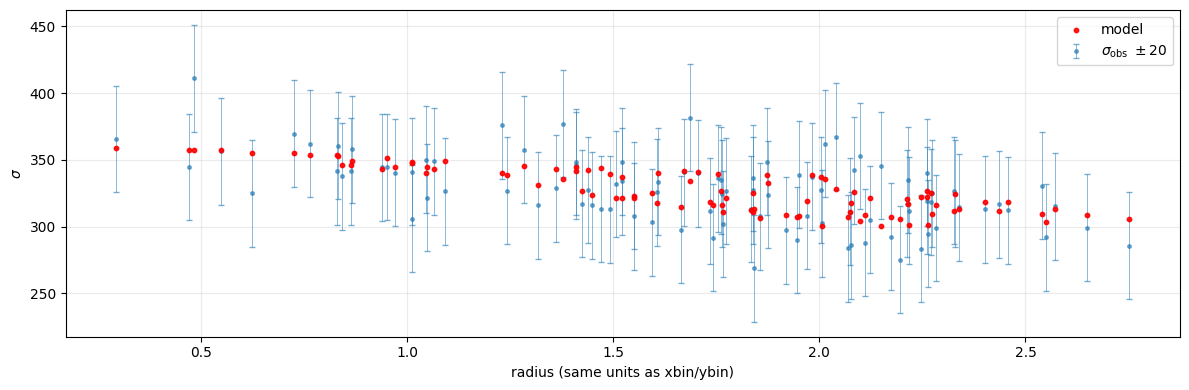

In [7]:
import numpy as np
import matplotlib.pyplot as plt

r = np.hypot(xbin, ybin).ravel()          
y_obs = sigma_obs.ravel()
y_mod = pred_model.ravel()

plt.figure(figsize=(12,4))
plt.errorbar(r, y_obs, yerr=40.0, fmt='o', ms=2.5, lw=0.8,
             elinewidth=0.6, capsize=2, alpha=0.6,
             label=r'$\sigma_{\rm obs}\ \pm 20$')
plt.scatter(r, y_mod, s=10, alpha=0.9, label='model', zorder=3, c = 'red')

plt.xlabel('radius (same units as xbin/ybin)')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
